# **Exploratory Data Analysis (EDA)** 🌍

Exploratory Data Analysis aime to:


*   Ensure Data **Quality**, **Validation**, and **Completeness**
*   Understand the structure, patterns, and relationships within a dataset



⚠️***Very Important Notice:***
- There are no fixed rules for EDA (Exploratory Data Analysis) or Data Cleaning.

- The methods you choose depend on your **understanding of the data** and the **goal** of your analysis.

- This notebook is just an introduction with *common use cases* and practical
examples for beginners.

Use it as a **guide**, but always think critically about what makes sense for your dataset!

In [88]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

**Use Case 1: Chack The Datatypes**
- Goal-> Make sure every column has the correct data type — because wrong types can cause errors or incorrect calculations later.

In [89]:
data = {
    'Name': ['Alice', 'Bob', 'Charlie'],
    'Age': ['25', 'None', '30'],
    'Salary': ['$4000', '$3500', '$5000'],
    'Phone': ['+1-202-555-0182', '202-555-0176', '202-555-0198']
}

df = pd.DataFrame(data)
df.head()


,Name,Age,Salary,Phone
0,Alice,25,$4000,+1-202-555-0182
1,Bob,None,$3500,202-555-0176
2,Charlie,30,$5000,202-555-0198


In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Name    3 non-null      object
 1   Age     3 non-null      object
 2   Salary  3 non-null      object
 3   Phone   3 non-null      object
dtypes: object(4)
memory usage: 228.0+ bytes


To change the datatype, we use **astype()** or **pd.to_numeric()** but in some cases we have only to use pd.to_numeric() becasue of the non-null and none-numerical values such as the word "None"

In [91]:
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

In [92]:
df.head()

,Name,Age,Salary,Phone
0,Alice,25.0,$4000,+1-202-555-0182
1,Bob,NaN,$3500,202-555-0176
2,Charlie,30.0,$5000,202-555-0198


In [93]:
df['Salary'] = df['Salary'].str.strip('$')
df['Salary'] = df['Salary'].astype('float')

In [94]:
df['Phone'] = df['Phone'].str.strip('+1')
df['Phone'] = df['Phone'].str.replace('-','')
df['Phone'] = df['Phone'].str.replace(' ','')
# df['Phone'] = df['Phone'].str.replace(r'\D', '', regex=True)
df['Phone'] = df['Phone'].astype('int')

In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Name    3 non-null      object 
 1   Age     2 non-null      float64
 2   Salary  3 non-null      float64
 3   Phone   3 non-null      int64  
dtypes: float64(2), int64(1), object(1)
memory usage: 228.0+ bytes


In [96]:
df.head()

,Name,Age,Salary,Phone
0,Alice,25.0,4000.0,2025550182
1,Bob,NaN,3500.0,2025550176
2,Charlie,30.0,5000.0,2025550198


**Use Case 2: Validate Numerical Ranges**

In [97]:
data = {
    'Name': ['Alice', 'Charlie', 'Dina', 'Ethan'],
    'Rating(stars)': [4.5, 5, 6, 3],
    'Age': [25, 40, -20, 28]
}

df = pd.DataFrame(data)
df.head()

,Name,Rating(stars),Age
0,Alice,4.5,25
1,Charlie,5.0,40
2,Dina,6.0,-20
3,Ethan,3.0,28


In [98]:
df.describe()

,Rating(stars),Age
count,4.000,4.000000
mean,4.625,18.250000
std,1.250,26.310644
min,3.000,-20.000000
25%,4.125,13.750000
50%,4.750,26.500000
75%,5.250,31.000000
max,6.000,40.000000


In [99]:
df['Age'] = df['Age'].apply('abs')

In [100]:
df['Rating(stars)'].replace(6, 5, inplace=True)
df['Rating(stars)'] = df['Rating(stars)'].replace(6, 5)

/tmp/ipykernel_1943/137559430.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Rating(stars)'].replace(6, 5, inplace=True)


In [101]:
df.head()

,Name,Rating(stars),Age
0,Alice,4.5,25
1,Charlie,5.0,40
2,Dina,5.0,20
3,Ethan,3.0,28


**Use Case 3: Incpect Unique Categories**

In [102]:
data = {
    'Name': ['Alice', 'Bob', 'Charlie', 'Dina', 'Ethan', 'Fatma', 'George'],
    'Gender': ['Female', 'Female', 'F', 'Woman', 'Male', 'M', 'Man'],
    'Subscribed': ['Yes', 'no', 'YES', 'No', 'yes', 'No', 'nO'],          # different capitalization
}

df = pd.DataFrame(data)
df.head()

,Name,Gender,Subscribed
0,Alice,Female,Yes
1,Bob,Female,no
2,Charlie,F,YES
3,Dina,Woman,No
4,Ethan,Male,yes


In [103]:
df.describe(include='object')

,Name,Gender,Subscribed
count,7,7,7
unique,7,6,6
top,Alice,Female,No
freq,1,2,2


In [104]:
df['Subscribed'].unique()

array(['Yes', 'no', 'YES', 'No', 'yes', 'nO'], dtype=object)

In [105]:
df['Subscribed'] = df['Subscribed'].str.upper()

In [106]:
df['Subscribed'].unique()

array(['YES', 'NO'], dtype=object)

In [107]:
df['Gender'].unique()

array(['Female', 'F', 'Woman', 'Male', 'M', 'Man'], dtype=object)

In [108]:
genders = {'F': 'Female',
           'Woman': 'Female',
           'M': 'Male',
           'Man': 'Male'}

df['Gender'] = df['Gender'].replace(genders)

In [109]:
df['Gender'].unique()

array(['Female', 'Male'], dtype=object)

**Use Case 4: Chack For Missing Values**

In [110]:
data = {
    'Name': ['Alice', 'Bob', np.nan, 'Dina', 'Ethan', 'Fatma'],
    'Age': [25, np.nan, 'None', 30, '', 28],
    'Salary': [4000, 3500, np.nan, 'None', 4200, 3900],
    'Department': ['HR', '', '', np.nan, 'None', 'Finance']
}

df = pd.DataFrame(data)
df.head()

,Name,Age,Salary,Department
0,Alice,25,4000,HR
1,Bob,NaN,3500,
2,NaN,None,NaN,
3,Dina,30,None,NaN
4,Ethan,,4200,None


In [111]:
df.isnull() #or isna

,Name,Age,Salary,Department
0,False,False,False,False
1,False,True,False,False
2,True,False,True,False
3,False,False,False,True
4,False,False,False,False
5,False,False,False,False


In [112]:
df.isnull().sum()

,0
Name,1
Age,1
Salary,1
Department,1


In [113]:
df['Department'].unique()

array(['HR', '', nan, 'None', 'Finance'], dtype=object)

In [114]:
df = df.replace(['None', ''], np.nan)

/tmp/ipykernel_1943/2634086036.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace(['None', ''], np.nan)


In [115]:
df.isnull().sum()

,0
Name,1
Age,3
Salary,2
Department,4


In [116]:
df.isnull().mean()*100

,0
Name,16.666667
Age,50.000000
Salary,33.333333
Department,66.666667


In [117]:
df.isna().all(axis=1)

,0
0,False
1,False
2,True
3,False
4,False
5,False


In [118]:
df.isna().all(axis=1).sum()

np.int64(1)

In [119]:
all_null_rows = df.isnull().all(axis=1)
all_null_rows = df.index[all_null_rows].tolist()
all_null_rows

[2]

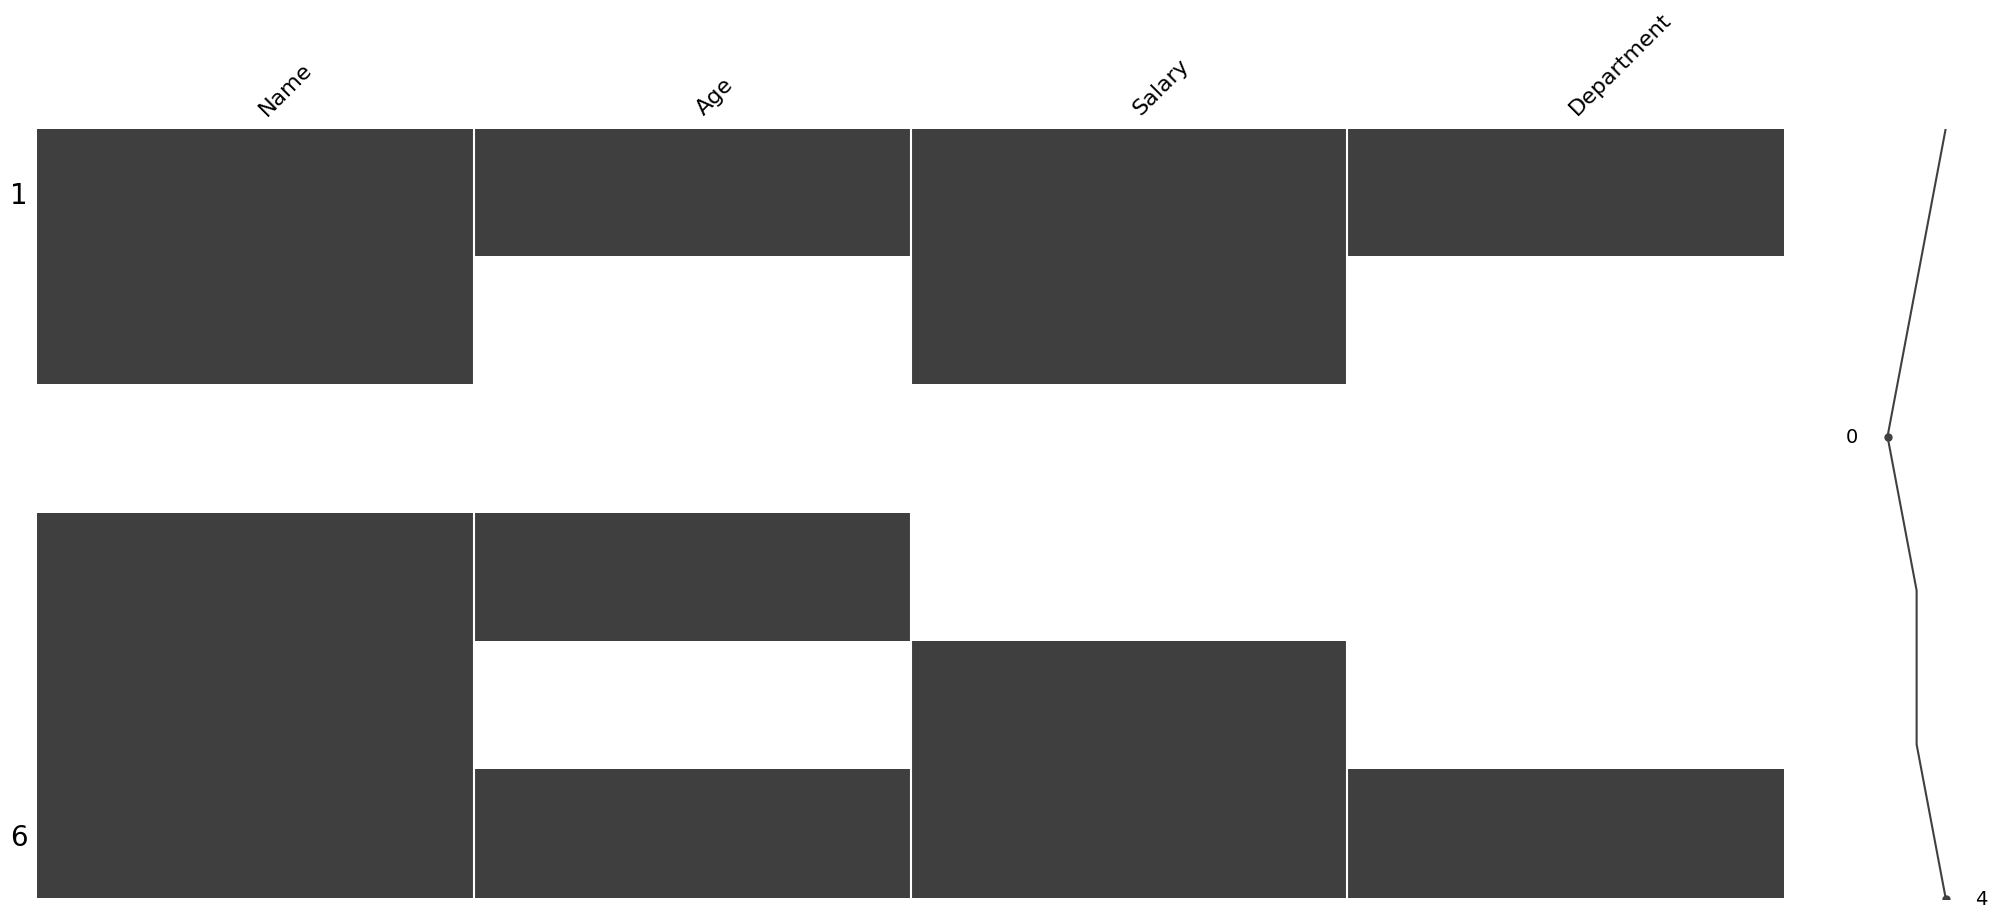

In [120]:
import missingno as msno
msno.matrix(df)
plt.show()

**Use Case 5: Chack For Duplicates**

In [121]:
data = {
    'Name': ['Alice', 'Bob', 'Charlie', 'Alice', 'Dina', 'Bob'],
    'Age': [25, 30, 35, 25, 28, 30],
    'Salary': [4000, 3500, 5000, 4000, 4200, 3500],
    'Department': ['HR', 'IT', 'Finance', 'HR', 'IT', 'IT']
}

df = pd.DataFrame(data)
df

,Name,Age,Salary,Department
0,Alice,25,4000,HR
1,Bob,30,3500,IT
2,Charlie,35,5000,Finance
3,Alice,25,4000,HR
4,Dina,28,4200,IT
5,Bob,30,3500,IT


In [122]:
df.duplicated()

,0
0,False
1,False
2,False
3,True
4,False
5,True


In [123]:
df.duplicated(keep=False)

,0
0,True
1,True
2,False
3,True
4,False
5,True


In [124]:
duplicates = df.duplicated(keep=False)
df[duplicates]

,Name,Age,Salary,Department
0,Alice,25,4000,HR
1,Bob,30,3500,IT
3,Alice,25,4000,HR
5,Bob,30,3500,IT


In [125]:
df.duplicated().sum()

np.int64(2)

In [126]:
df['ID'] = [1, 2, 3, 4, 5, 6]

In [127]:
df.head(6)

,Name,Age,Salary,Department,ID
0,Alice,25,4000,HR,1
1,Bob,30,3500,IT,2
2,Charlie,35,5000,Finance,3
3,Alice,25,4000,HR,4
4,Dina,28,4200,IT,5
5,Bob,30,3500,IT,6


In [128]:
df.duplicated().sum()

np.int64(0)

In [129]:
df.duplicated(subset=['ID','Name'])

,0
0,False
1,False
2,False
3,False
4,False
5,False


In [130]:
df.duplicated(subset=['Name']).sum()

np.int64(2)

**Use Case 6: Detecting Outliers**

In [131]:
data = {
    'Name': ['Alice', 'Bob', 'Charlie', 'Dina', 'Ethan', 'Fatma', 'George'],
    'Age': [25, 30, 35, 28, 200, 27, 29],
    'Salary': [4000, 3500, 5000, 4200, 3800, 100000, 3900],
    'Rating': [4.5, 5, 5, 4, 3, 5, 3]
}

df = pd.DataFrame(data)
df

,Name,Age,Salary,Rating
0,Alice,25,4000,4.5
1,Bob,30,3500,5.0
2,Charlie,35,5000,5.0
3,Dina,28,4200,4.0
4,Ethan,200,3800,3.0
5,Fatma,27,100000,5.0
6,George,29,3900,3.0


In [132]:
df.describe()

,Age,Salary,Rating
count,7.000000,7.000000,7.000000
mean,53.428571,17771.428571,4.214286
std,64.706664,36262.410027,0.906327
min,25.000000,3500.000000,3.000000
25%,27.500000,3850.000000,3.500000
50%,29.000000,4000.000000,4.500000
75%,32.500000,4600.000000,5.000000
max,200.000000,100000.000000,5.000000


In [133]:
numeric_cols = ['Age', 'Salary', 'Rating']

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"Outliers in {col}:")
    print(outliers[[col]])
    print("-"*30)


Outliers in Age:
   Age
4  200
------------------------------
Outliers in Salary:
   Salary
5  100000
------------------------------
Outliers in Rating:
Empty DataFrame
Columns: [Rating]
Index: []
------------------------------


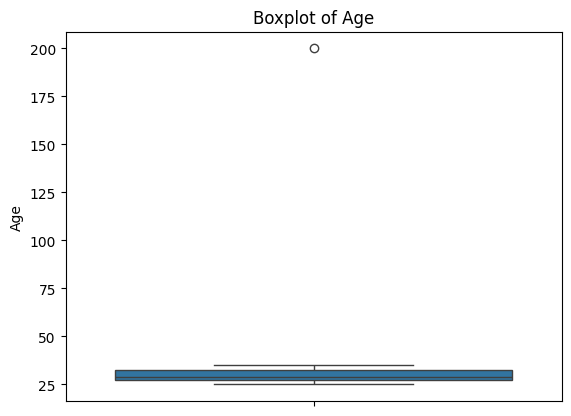

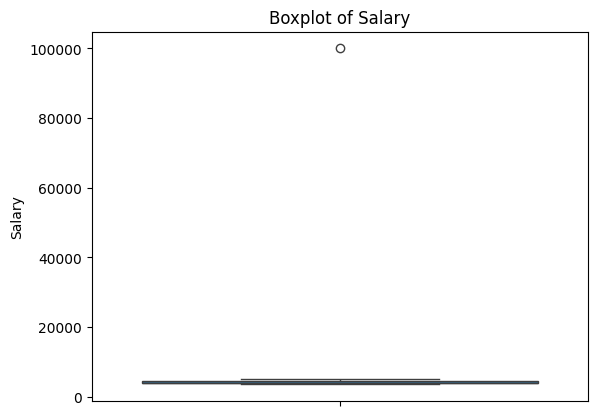

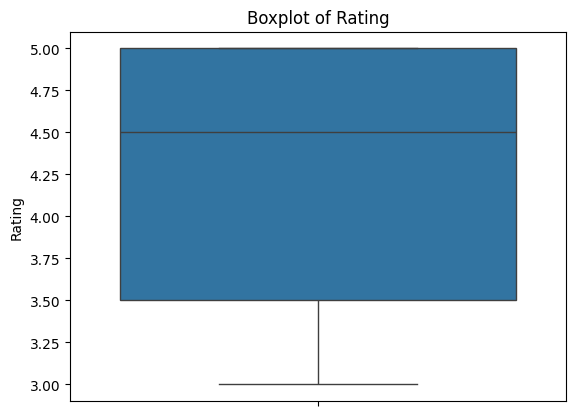

In [134]:
for col in numeric_cols:
    sns.boxplot(y=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

**Use Case 7: Explore Distributions**

Understand the frequency, spread, and shape of each variable.


In [135]:

data = {
    'Name': ['Alice', 'Bob', 'Charlie', 'Dina', 'Ethan', 'Fatma', 'Ahmed', 'Hana', 'Ibrahim', 'Jana'],
    'Age': [25, 30, 35, 28, 32, 27, 29, 31, 40, 26],
    'Salary': [4000, 3500, 5000, 4200, 3800, 3900, 4100, 4300, 4800, 3700],
    'Rating': [4, 5, 4, 3, 5, 4, 3, 5, 4, 3],
    'Department': ['HR', 'IT', 'Finance', 'HR', 'IT', 'Finance', 'IT', 'HR', 'Finance', 'IT']
}

df = pd.DataFrame(data)
df

,Name,Age,Salary,Rating,Department
0,Alice,25,4000,4,HR
1,Bob,30,3500,5,IT
2,Charlie,35,5000,4,Finance
3,Dina,28,4200,3,HR
4,Ethan,32,3800,5,IT
5,Fatma,27,3900,4,Finance
6,Ahmed,29,4100,3,IT
7,Hana,31,4300,5,HR
8,Ibrahim,40,4800,4,Finance
9,Jana,26,3700,3,IT


In [136]:
df.describe()

,Age,Salary,Rating
count,10.000000,10.000000,10.000000
mean,30.300000,4130.000000,4.000000
std,4.522782,471.522357,0.816497
min,25.000000,3500.000000,3.000000
25%,27.250000,3825.000000,3.250000
50%,29.500000,4050.000000,4.000000
75%,31.750000,4275.000000,4.750000
max,40.000000,5000.000000,5.000000


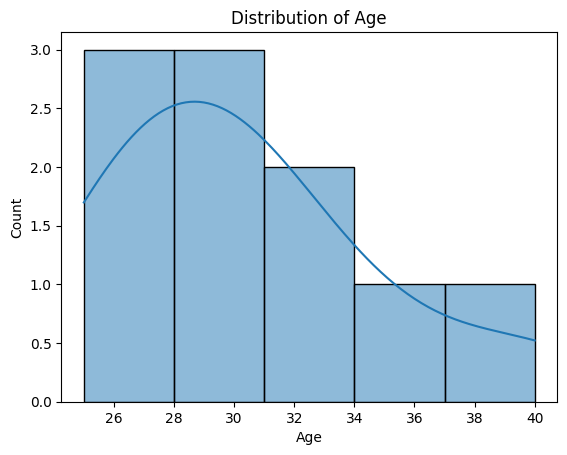

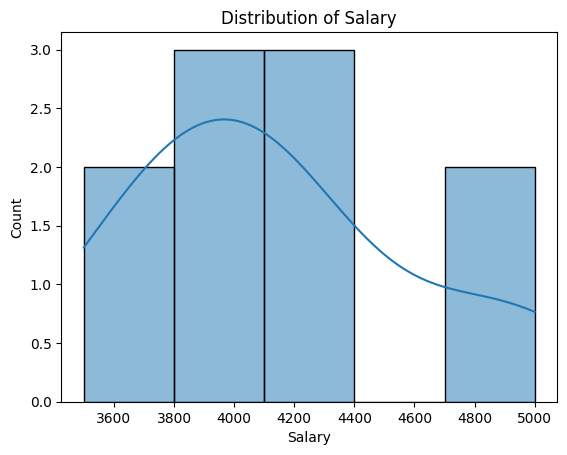

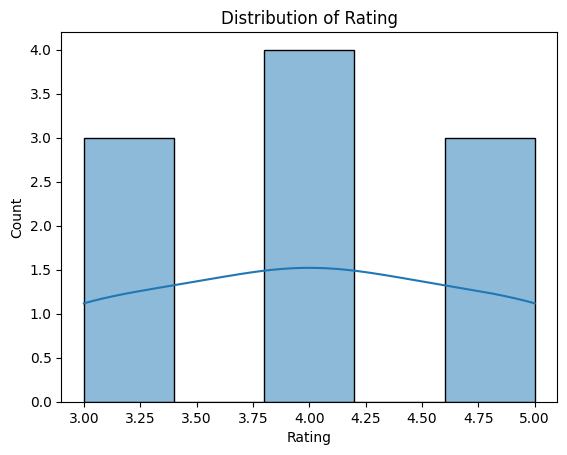

In [137]:
numeric_cols = ['Age', 'Salary', 'Rating']

for col in numeric_cols:
    sns.histplot(df[col], kde=True, bins=5)
    plt.title(f"Distribution of {col}")
    plt.show()


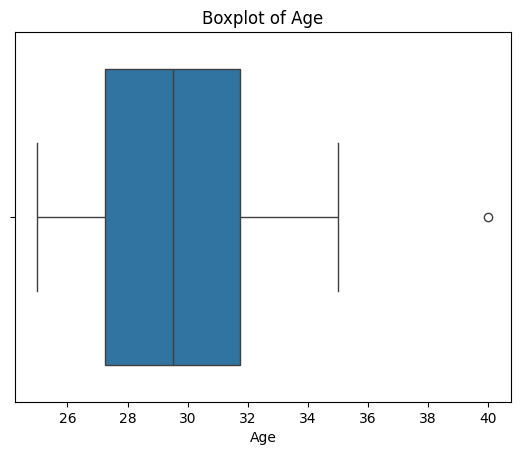

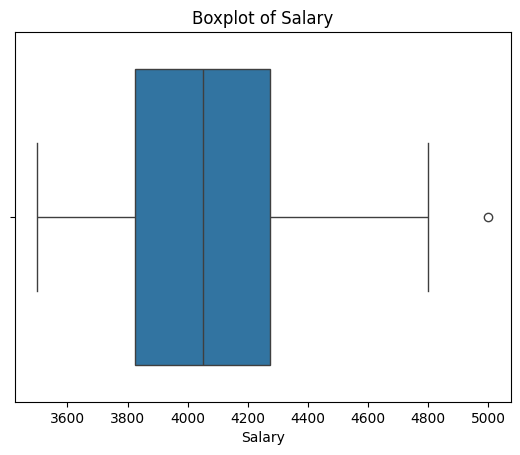

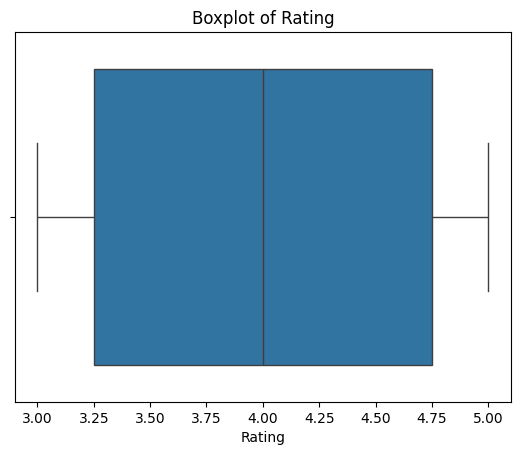

In [138]:
for col in numeric_cols:
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()


**Use Case 8: Explore Relationships**

1- Numeric vs Numeric — Correlation

             Age    Salary    Rating
Age     1.000000  0.703890  0.300883
Salary  0.703890  1.000000 -0.115441
Rating  0.300883 -0.115441  1.000000


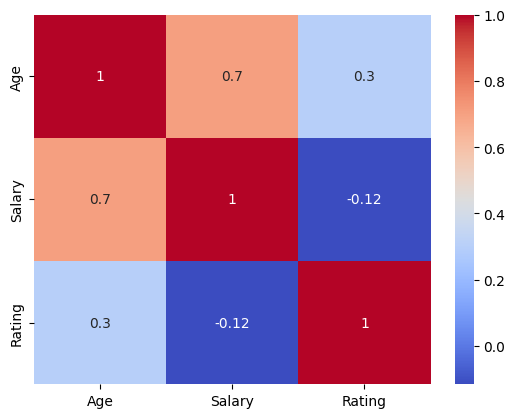

In [139]:
corr = df[numeric_cols].corr()
print(corr)

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

2- Numeric vs Categorical — Boxplots

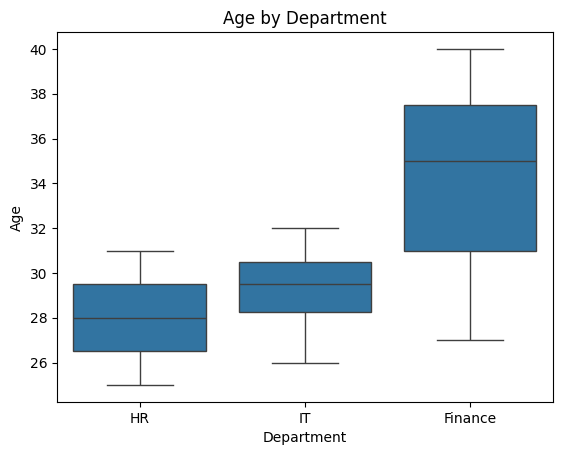

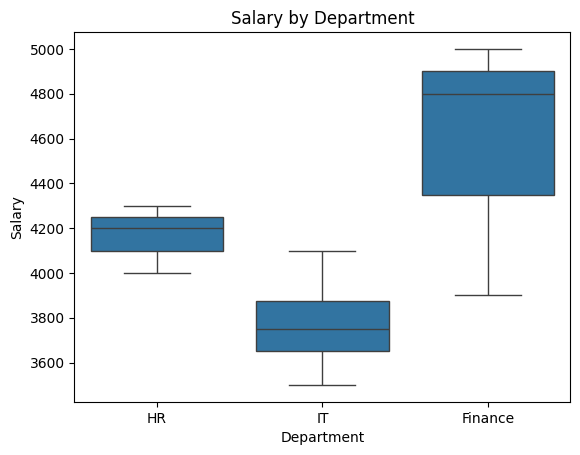

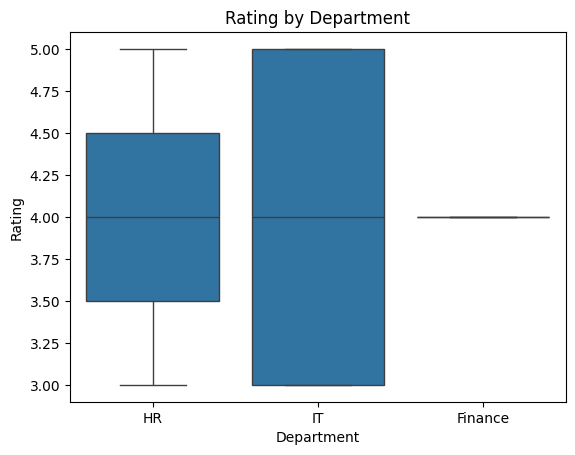

In [140]:
for col in numeric_cols:
    sns.boxplot(x=df['Department'], y=df[col])
    plt.title(f"{col} by Department")
    plt.show()

3- Categorical vs Categorical - Countplot

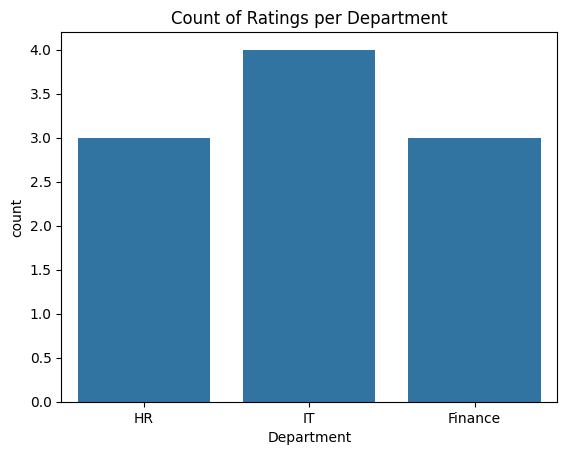

In [141]:
sns.countplot(x='Department', data=df)
plt.title("Count of Ratings per Department")
plt.show()

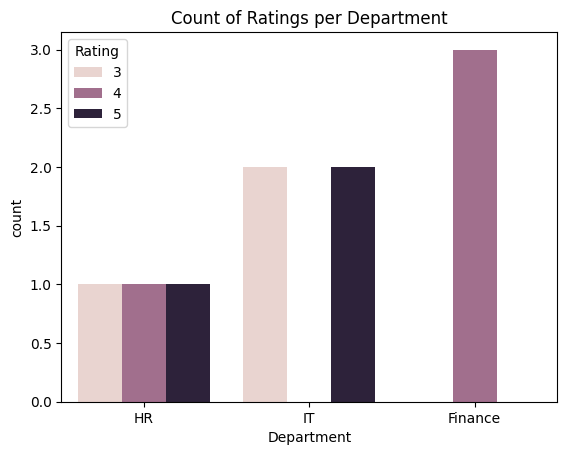

In [142]:
sns.countplot(x='Department', hue='Rating', data=df)
plt.title("Count of Ratings per Department")
plt.show()